# Produce plots for the paper on MLST

In [1]:
import os
import torch
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps, patches

from ttnml.ml import TTNModel
from ttnml.tn import check_correct_init, TIndex, TTN
from ttnml.tn.algebra import contract_up
from ttnml.utils import dataloaders, plot_correlations, plot_feat_en
from torchinfo import summary
FONTSIZE = 14
torch.set_num_threads(12)

quimb not installed, partial_dm will not work


## Plot correlations as learnd by the model vs from dataset

They want to see LHCb, but the plots are big, make them smaller

In [2]:
labels = ["LHCb dataset correlations"]
bbdata_feat_labels = [r"$q^\mu$", r"$p_T^\mu$", r"$r^\mu$", r"$q^K$", r"$p_T^K$", r"$r^K$", r"$q^\pi$", r"$p_T^\pi$", r"$r^\pi$", r"$q^e$", r"$p_T^e$", r"$r^e$", r"$q^p$", r"$p_T^p$", r"$r^p$", r"$q^{jet}$"]

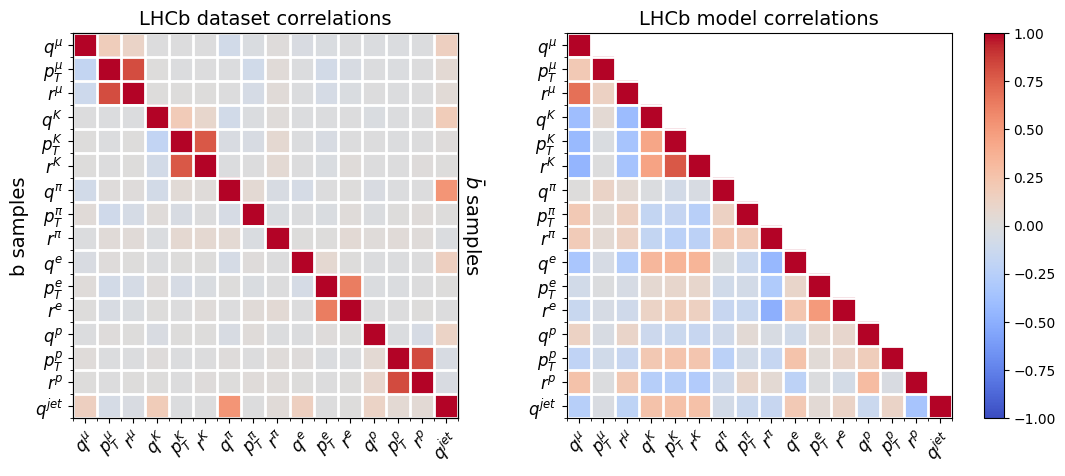

In [42]:
# load model correlations
slurm_id=202
fold = 0
fname = glob(f"trained_models/bbdata_models/data/correlations*fold{fold}_{slurm_id}*.npy")[0]
corr_model = np.load(fname)

# load dataset correlations
datadir = "data/bbdata/asym_train.csv"
df = pd.read_csv(datadir, header=None)
df.columns = ["label"] + dataloaders.bbdata_features.tolist()
for col in df.columns:
    if "pt" in col:
        df[col] = np.log1p(df[col])
signal = df[df["label"] == 1].drop(columns=["label"])
background = df[df["label"] == -1].drop(columns=["label"])
corr = signal.corr().to_numpy()
corr[np.triu_indices(corr.shape[0], k=1)] = background.corr().to_numpy().T[np.triu_indices(corr.shape[0], k=1)]
corr = corr[:,:,np.newaxis]


fig, axs = plt.subplots(1, 3, figsize=(13, 5), width_ratios=[12, 12, 0.55])

im_data = plot_correlations(corr, features=bbdata_feat_labels, labels=labels, axs=axs[0], annot=False)
im_model = plot_correlations(corr_model, features=bbdata_feat_labels, labels=["LHCb model correlations"], axs=axs[1], annot=False)

axs[0].set_ylabel("b samples", fontsize=FONTSIZE)
pos = axs[0].get_position()
bg_ax = axs[0].twinx()
bg_ax.set_position(pos)

bg_ax.set_ylabel(r"$\bar b$ samples", fontsize=FONTSIZE, rotation=-90, labelpad=20)
bg_ax.set_yticks([])
#axs[1].set_yticklabels([])

# shift the colorbar axes slightly to the left to improve spacing
cb_pos = axs[2].get_position()
delta = 0.04
new_cb_pos = [cb_pos.x0 - delta, cb_pos.y0, cb_pos.width, cb_pos.height]
axs[2].set_position(new_cb_pos)
# draw the colorbar into the adjusted axes
plt.colorbar(im_model[2], cax=axs[2])

In [43]:
fig.savefig("images/lhcb_corr.pdf")

## Plot feature entropy of LHCb

In [22]:
features_entropies = glob("trained_models/bbdata_models/data/features_entropy_bbdata_*20*.npy")

test = []
for fname in features_entropies:
    entropies = np.load(fname).mean(axis=1)
    test.append(entropies)

test = np.stack(test, axis=0)
ent_means = test.mean(0)[:,np.newaxis]
ent_stds = test.std(0)

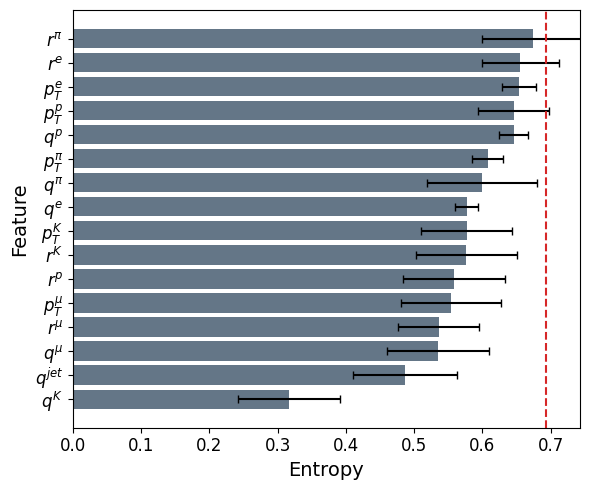

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sort_idx = np.argsort(ent_means[:,0])

plot_feat_en(ent_means[sort_idx,:], np.array(bbdata_feat_labels)[sort_idx], "LHCb", 2, yerr=ent_stds, axs=[ax], color='#647687')

fig.tight_layout()
#fig.savefig("images/lhcb_feat_ent.pdf")

In [24]:
sort_idx

array([ 3, 15,  0,  2,  1, 14,  5,  4,  9,  6,  7, 12, 13, 10, 11,  8])

# plot feat ent for titanic

In [ ]:
DATASET = "Titanic"

In [25]:
features_entropies = glob(f"trained_models/{DATASET.lower()}_models/data/features_entropy_{DATASET.lower()}_*20284*.npy")

test = []
for fname in features_entropies:
    entropies = np.load(fname).mean(axis=1)
    test.append(entropies)

test = np.stack(test, axis=0)
ent_means = test.mean(0)[:,np.newaxis]
ent_stds = test.std(0)

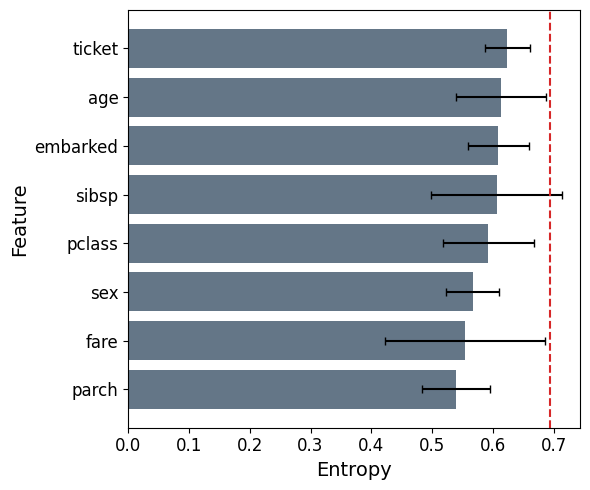

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sort_idx = np.argsort(ent_means[:,0])

plot_feat_en(ent_means[sort_idx,:], np.array(dataloaders.titanic_features)[sort_idx], DATASET, 2, yerr=ent_stds, axs=[ax], color='#647687')

fig.tight_layout()
fig.savefig(f"images/{DATASET.lower()}_feat_ent.pdf")

In [27]:
sort_idx

array([4, 6, 1, 0, 3, 7, 2, 5])

In [16]:
sort_idx

array([4, 6, 1, 0, 3, 7, 2, 5])

In [18]:
np.array(dataloaders.titanic_features)

array(['pclass', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'embarked'], dtype='<U8')

# Accuracy vs bd

# Plots for the second papaer

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
qmi_poly = np.load("trained_models/hls150_models/data/features_qmi_hls150_bd16_poly_237033.npy")
qmi_int = np.load("trained_models/hls150_models_interaction/data/features_qmi_hls150_bd16_poly_237047.npy")